# Installations & Imports

In [1]:
!pip install cobra -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.9/141.9 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 90.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 62.3 MB/s eta 0:00:00


In [2]:
import cobra
import numpy as np
import matplotlib.pyplot as plt

# Pastoris

In [3]:
import logging
logging.getLogger("cobra").setLevel(logging.ERROR)
pmodel = cobra.io.read_sbml_model("/content/mbt212871-sup-0003-AppendixS3.xml")

In [4]:
pmodel.reactions.Ex_glc_D.bounds = (-5,0)
pmodel.reactions.Ex_glyc.bounds = (0,0)
pmodel.reactions.Ex_o2.bounds = (-10,10)

In [5]:
print(pmodel)
print(f"Reactions : {len(pmodel.reactions)}")
print(f"Metabolites: {len(pmodel.metabolites)}")
print(f"Genes      : {len(pmodel.genes)}")

# Quick sanity check — can it grow?
sol = pmodel.optimize()
print(f"Objective  : {sol.objective_value:.4f}")
print(f"Status     : {sol.status}")

iMT1026v3
Reactions : 2237
Metabolites: 1706
Genes      : 1026
Objective  : 0.5806
Status     : optimal


# Objective2: Minimum Oxygen for Viability

In [6]:
obj2_aerobic = pmodel.copy()

In [7]:
obj2_aerobic.reactions.get_by_id("Ex_o2").bounds = (-10,10)
obj2_aerobic.slim_optimize()

0.5806242875796614


Max Growth        : 0.5806 h⁻¹
Viability threshold : 0.0290 h⁻¹  (5% of max)

Minimum viable O₂ uptake : 0.0503 mmol gDW⁻¹ h⁻¹
Growth at that point     : 0.0744 h⁻¹
CO₂ at that point        : 9.1898 mmol gDW⁻¹ h⁻¹


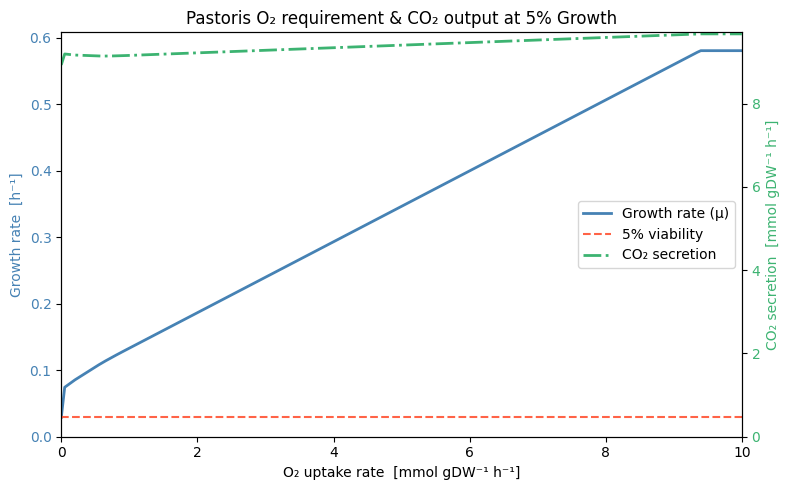

In [8]:
o2_rxn_id = "Ex_o2"
co2_rxn_id = "Ex_co2" # CO2 exchange

# ── 2. Max aerobic growth & viability threshold ───────────────────────────────
with obj2_aerobic:
    sol_max = obj2_aerobic.optimize()
    maxGrowth  = sol_max.objective_value

viability_threshold = 0.05 * maxGrowth
print(f"\nMax Growth        : {maxGrowth:.4f} h⁻¹")
print(f"Viability threshold : {viability_threshold:.4f} h⁻¹  (5% of max)")

# ── 3. Scan O₂ — record growth AND CO₂ ───────────────────────────────────────
o2_max_uptake = abs(obj2_aerobic.reactions.get_by_id(o2_rxn_id).lower_bound)
o2_scan       = np.linspace(0, o2_max_uptake, 200)

growth_rates = []
co2_fluxes   = []

with obj2_aerobic:
    for o2 in o2_scan:
        obj2_aerobic.reactions.get_by_id(o2_rxn_id).lower_bound = -o2
        sol = obj2_aerobic.optimize()

        if sol.status == "optimal":
            growth_rates.append(sol.objective_value)
            co2_fluxes.append(sol.fluxes[co2_rxn_id])
        else:
            growth_rates.append(0.0)
            co2_fluxes.append(0.0)

growth_rates = np.array(growth_rates)
co2_fluxes   = np.array(co2_fluxes)

# ── 4. Minimum viable O₂ ─────────────────────────────────────────────────────
viable_mask = growth_rates >= viability_threshold
if viable_mask.any():
    min_viable_o2 = o2_scan[viable_mask][0]
    growth_at_min = growth_rates[viable_mask][0]
    co2_at_min    = co2_fluxes[viable_mask][0]
    print(f"\nMinimum viable O₂ uptake : {min_viable_o2:.4f} mmol gDW⁻¹ h⁻¹")
    print(f"Growth at that point     : {growth_at_min:.4f} h⁻¹")
    print(f"CO₂ at that point        : {co2_at_min:.4f} mmol gDW⁻¹ h⁻¹")

# ── 5. Plot ───────────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()

ln1 = ax1.plot(o2_scan, growth_rates, color="steelblue", lw=2, label="Growth rate (μ)")
ax1.axhline(viability_threshold, color="tomato", lw=1.5, ls="--", label=f"5% viability")

ln2 = ax2.plot(o2_scan, co2_fluxes, color="mediumseagreen", lw=2, ls="-.", label="CO₂ secretion")

ax1.set_xlabel("O₂ uptake rate  [mmol gDW⁻¹ h⁻¹]")
ax1.set_ylabel("Growth rate  [h⁻¹]", color="steelblue")
ax2.set_ylabel("CO₂ secretion  [mmol gDW⁻¹ h⁻¹]", color="mediumseagreen")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax2.tick_params(axis="y", labelcolor="mediumseagreen")

ax1.set_xlim(0, o2_max_uptake)
ax1.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="center right")

plt.title("Pastoris O₂ requirement & CO₂ output at 5% Growth")
plt.tight_layout()
plt.show()

# Objective3: Minimum Oxygen for Viability while producing proteins

In [9]:
obj3_master_model = pmodel.copy()

## Adding GFP + Anti-GFP Nanobody Reactions

### Create the Amino Acids Dictionary

In [10]:
# All 20 amino acid names to search
aa_names = {
    'A': 'L-alanine',       'R': 'L-arginine',      'N': 'L-asparagine',
    'D': 'L-aspartate',     'C': 'L-cysteine',       'Q': 'L-glutamine',
    'E': 'L-glutamate',     'G': 'L-glycine',           'H': 'L-histidine',
    'I': 'L-isoleucine',    'L': 'L-leucine',         'K': 'L-lysine',
    'M': 'L-methionine',    'F': 'L-phenylalanine',   'P': 'L-proline',
    'S': 'L-serine',        'T': 'L-threonine',       'W': 'L-tryptophan',
    'Y': 'L-tyrosine',      'V': 'L-valine'
}

aa_metabolites = {}

for one_letter, name in aa_names.items():
    hits = [m for m in obj3_master_model.metabolites
            if m.name.lower() == name.lower() and m.compartment == 'c']
    if hits:
        aa_metabolites[one_letter] = hits[0]


In [11]:
for m in pmodel.metabolites:
  if "Glycine" in m.name:
    print(m.id)
    print(m.name)

gly_c
Glycine
gly_m
Glycine
gly_e
Glycine


In [12]:
# Mapping of amino acid single letters to their likely IDs in the iBsu1147 model
aa_metabolites_ids = {
    'A': 'ala__L_c', 'R': 'arg__L_c', 'N': 'asn__L_c', 'D': 'asp__L_c',
    'C': 'cys__L_c', 'Q': 'gln__L_c', 'E': 'glu__L_c', 'G': 'gly_c',
    'H': 'his__L_c', 'I': 'ile__L_c', 'L': 'leu__L_c', 'K': 'lys__L_c',
    'M': 'met__L_c', 'F': 'phe__L_c', 'P': 'pro__L_c', 'S': 'ser__L_c',
    'T': 'thr__L_c', 'W': 'trp__L_c', 'Y': 'tyr__L_c', 'V': 'val__L_c'
}

aa_metabolites = {}
for letter, mid in aa_metabolites_ids.items():
    try:
        aa_metabolites[letter] = obj3_master_model.metabolites.get_by_id(mid)
    except KeyError:
        # Fallback: try searching by name if the standard ID doesn't work
        name_to_search = aa_names[letter].lower()
        hits = [m for m in obj3_master_model.metabolites if m.name.lower() == name_to_search and m.compartment == 'c']
        if hits:
            aa_metabolites[letter] = hits[0]
        else:
          print(f"Warning: No metabolite found for {letter} ({name_to_search})")

print(f"Loaded {len(aa_metabolites)}/20 amino acids.")
for letter, met in sorted(aa_metabolites.items()):
    print(f"  {letter} | {met.id} | {met.name}")

Loaded 20/20 amino acids.
  A | ala_L_c | L-Alanine
  C | cys_L_c | L-Cysteine
  D | asp_L_c | L-Aspartate
  E | glu_L_c | L-Glutamate
  F | phe_L_c | L-Phenylalanine
  G | gly_c | Glycine
  H | his_L_c | L-Histidine
  I | ile_L_c | L-Isoleucine
  K | lys_L_c | L-Lysine
  L | leu_L_c | L-Leucine
  M | met_L_c | L-Methionine
  N | asn_L_c | L-Asparagine
  P | pro_L_c | L-Proline
  Q | gln_L_c | L-Glutamine
  R | arg_L_c | L-Arginine
  S | ser_L_c | L-Serine
  T | thr_L_c | L-Threonine
  V | val_L_c | L-Valine
  W | trp_L_c | L-Tryptophan
  Y | tyr_L_c | L-Tyrosine


### Assign Variables to important molecules

In [13]:
atp  = obj3_master_model.metabolites.get_by_id('atp_c')  # ATP
adp  = obj3_master_model.metabolites.get_by_id('adp_c')  # ADP
pi   = obj3_master_model.metabolites.get_by_id('pi_c')   # phosphate (Pi)
h2o  = obj3_master_model.metabolites.get_by_id('h2o_c')  # H2O
h = obj3_master_model.metabolites.get_by_id('h_c')     # H+

print(f"ATP:  {atp.id} | {atp.name}")
print(f"ADP:  {adp.id} | {adp.name}")
print(f"Pi:   {pi.id}  | {pi.name}")
print(f"H2O:  {h2o.id} | {h2o.name}")
print(f"H+:  {h.id} | {h.name}")

ATP:  atp_c | ATP
ADP:  adp_c | ADP
Pi:   pi_c  | Phosphate
H2O:  h2o_c | H2O
H+:  h_c | H+


### GFP

In [14]:
from collections import Counter

# GFP (Uniprot P42212)
GFP_SEQ = "MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKFICTTGKLPVPWPTLVTTFSYGVQCFSRYPDHMKQHDFFKSAMPEGYVQERTIFFKDDGNYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNYNSHNVYIMADKQKNGIKVNFKIRHNIEDGSVQLADHYQQNTPIGDGPVLLPDNHYLSTQSALSKDPNEKRDHMVLLEFVTAAGITHGMDELYK"

aa_counts = Counter(GFP_SEQ)
n_aa = len(GFP_SEQ)

In [15]:
from cobra import Reaction, Metabolite

# Create the GFP metabolite

GFP = Metabolite(
    'GFP',
    name='Green Flourescent Protein',
    compartment='c'
)

# the synthesis reaction

GFP_rxn = Reaction('GFP_SYNTH')
GFP_rxn.name = 'GFP Synthesis'
GFP_rxn.lower_bound = 0      # irreversible, can only go forward
GFP_rxn.upper_bound = 1000

stoich = {}

# CONSUMED

# amino acids
for aa_letter, count in aa_counts.items():
    met = aa_metabolites[aa_letter]
    stoich[met] = -count

# ATP (4 equivalents per amino acid)
stoich[atp] = -4 * n_aa

# H2O for tRNA charging (1 per AA)
# but each formed peptide bond gives back 1 H2O molecule
# 238 H2O for each AA & 237 H2O from each peptide bond so we end up with 1 H2O consumed
stoich[h2o] = -1

# PRODUCED

# ADP + Pi from ATP hydrolysis
stoich[adp] = 4 * n_aa
stoich[pi]  = 4 * n_aa

# H+
stoich[h] = n_aa - 1

# The GFP itself
stoich[GFP] = 1

GFP_rxn.add_metabolites(stoich)

In [16]:
# Demand reaction

GFP_demand = Reaction('GFP_DEMAND')
GFP_demand.name = 'GFP Demand Sink'
GFP_demand.lower_bound = 0
GFP_demand.upper_bound = 1000
GFP_demand.add_metabolites({GFP: -1})

# Add both reactions to the obj3_master_model

obj3_master_model.add_reactions([GFP_rxn, GFP_demand])

### Anti-GFP nanobody

In [17]:
from collections import Counter

# Anti-GFP VHH nanobody (Rothbauer et al.) - https://www.rcsb.org/3d-view/3K1K
NANOBODY_SEQ = (
    "MAQVQLQESGGGLVQAGGSLRLSCAASGRTFSSYAMGWFRQAPGKEREFVS"
    "AISWSGGSTYYADSVKGRFTISRDNAKNTVYLQMNSLKPEDTAVYYCAA"
    "KLLNPYWGQGTQVTVSS"
)

aa_counts = Counter(GFP_SEQ)
n_aa = len(GFP_SEQ)

In [18]:
from cobra import Reaction, Metabolite

# Create the nanobody as a pseudometabolite

nanobody = Metabolite(
    'nanobody_vhh_c',
    name='Anti-GFP VHH Nanobody (reference)',
    compartment='c'
)

# the synthesis reaction

nanobody_rxn = Reaction('NB_SYNTH')
nanobody_rxn.name = 'Nanobody VHH Synthesis'
nanobody_rxn.lower_bound = 0      # irreversible, can only go forward
nanobody_rxn.upper_bound = 1000

stoich = {}

# CONSUMED

# amino acids
for aa_letter, count in aa_counts.items():
    met = aa_metabolites[aa_letter]
    stoich[met] = -count

# ATP (4 equivalents per amino acid)
stoich[atp] = -4 * n_aa

# H2O for tRNA charging (1 per AA)
# but each formed peptide bond gives back 1 H2O molecule
# 115 H2O for each AA & 114 H2O from each peptide bond so we end up with 1 H2O consumed
stoich[h2o] = -1

# PRODUCED

# ADP + Pi from ATP hydrolysis
stoich[adp] = 4 * n_aa
stoich[pi]  = 4 * n_aa

# H+
stoich[h] = n_aa - 1

# The nanobody itself
stoich[nanobody] = 1

nanobody_rxn.add_metabolites(stoich)

In [19]:
# Demand reaction

nb_demand = Reaction('NB_DEMAND')
nb_demand.name = 'Nanobody Demand Sink'
nb_demand.lower_bound = 0
nb_demand.upper_bound = 1000
nb_demand.add_metabolites({nanobody: -1})

# Add both reactions to the obj3_master_model

obj3_master_model.add_reactions([nanobody_rxn, nb_demand])

## Plotting

In [20]:
obj3_aerobic = obj3_master_model.copy()

In [21]:
obj3_aerobic.reactions.get_by_id("Ex_o2").bounds = (-10,10)
obj3_aerobic.slim_optimize()

0.5806241814411497

At minimum viable O₂ (0.0503 mmol gDW⁻¹ h⁻¹):
  Combined production flux : 0.0016 mmol gDW⁻¹ h⁻¹


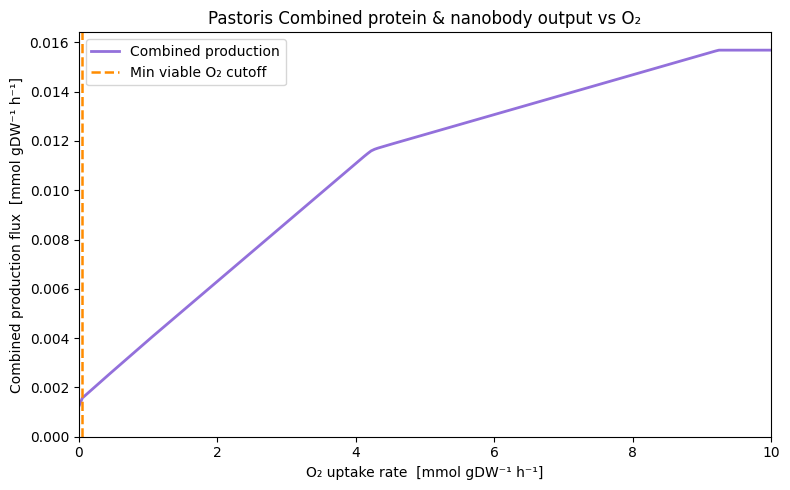

In [22]:
PROTEIN_RXN_ID  = "GFP_DEMAND"
NANOBODY_RXN_ID = "NB_DEMAND"
o2_rxn_id = "Ex_o2"

MIN_VIABLE_O2 = 0.0503   # mmol gDW⁻¹ h⁻¹

# ── 1. Calculate max growth for threshold ─────────────
with obj3_aerobic as wt:
    mu_max = wt.optimize().objective_value

viability_threshold = 0.05 * mu_max

def set_production_objective(model):
    model.objective = {
        model.reactions.get_by_id(PROTEIN_RXN_ID) : 0.5,
        model.reactions.get_by_id(NANOBODY_RXN_ID): 0.5,
    }

# ── 2. O₂ scan ────────────────────────────────────────────────────────────────
o2_max_uptake = abs(obj3_aerobic.reactions.get_by_id(o2_rxn_id).lower_bound)
o2_scan       = np.linspace(0, o2_max_uptake, 200)

combined_fluxes = []

with obj3_aerobic as model:
    # Correctly identify biomass reaction inside the context
    biomass_rxn_obj = model.objective.expression.atoms # Get atoms of the linear expression
    # Typically, the first reaction in the objective list is the biomass one
    biomass_rxn = list(model.objective.variables)[0].name.replace('reverse_', '').split('_')[0]
    # Safer way: Use the known biomass ID for yeast-GEM
    model.reactions.Ex_biomass.lower_bound = viability_threshold

    set_production_objective(model)

    for o2 in o2_scan:
        model.reactions.get_by_id(o2_rxn_id).lower_bound = -o2
        sol = model.optimize()

        if sol.status == "optimal":
            combined_fluxes.append(sol.fluxes[PROTEIN_RXN_ID] +
                                   sol.fluxes[NANOBODY_RXN_ID])
        else:
            combined_fluxes.append(np.nan)

combined_fluxes = np.array(combined_fluxes)

# ── 3. Production at the minimum viable O₂ cutoff ────────────────────────────
cutoff_idx        = np.argmin(np.abs(o2_scan - MIN_VIABLE_O2))
production_at_min = combined_fluxes[cutoff_idx]

print(f"At minimum viable O₂ ({MIN_VIABLE_O2} mmol gDW⁻¹ h⁻¹):")
print(f"  Combined production flux : {production_at_min:.4f} mmol gDW⁻¹ h⁻¹")

# ── 4. Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(o2_scan, combined_fluxes, color="mediumpurple", lw=2, label="Combined production")
ax.axvline(MIN_VIABLE_O2, color="darkorange", lw=1.8, ls="--",
           label=f"Min viable O₂ cutoff")

ax.set_xlabel("O₂ uptake rate  [mmol gDW⁻¹ h⁻¹]")
ax.set_ylabel("Combined production flux  [mmol gDW⁻¹ h⁻¹]")
ax.set_xlim(0, o2_max_uptake)
ax.set_ylim(bottom=0)
ax.legend()
ax.set_title("Pastoris Combined protein & nanobody output vs O₂")
plt.tight_layout()
plt.show()